In [2]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch import nn
from typing import Any, Dict, Optional, Union
from tqdm import tqdm
import json
import scipy.stats as stats
import numpy as np
from sklearn.preprocessing import StandardScaler


from causalflows.flows import CausalMAF, CausalNSF
from causalflows.scms import SCM, CausalEquations

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Import our Knowledge graphs

#NOTE we need to put 1 in the diagonal of the adjacency matrix

In [24]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

#loaded_graphs=loaded_graphs[0:2]
selected_graph = loaded_graphs[0]  
variables = selected_graph['variables']
adjacency_matrix = selected_graph['adjacency_matrix']

adj_array = np.array(adjacency_matrix)
# Add ones to the diagonal
np.fill_diagonal(adj_array, 1)

# Convert to torch tensor (boolean)
adjacency = torch.tensor(adj_array, dtype=torch.bool)
adjacency

tensor([[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [False,  True, False,  True, False, False, False],
        [ True,  True, False,  True,  True, False, False],
        [ True,  True, False,  True, False,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]])

In [4]:
# Load ground truth model FIRST
checkpoint_gt = torch.load('saved_models_validation/flow_ground_truth.pt',  map_location=torch.device('cpu'),weights_only=False)
scaler_gt = checkpoint_gt['scaler']  # Usar el scaler guardado
gt_variables = checkpoint_gt['variables']

## Import our diabetes dataset

In [5]:
data_df = pd.read_csv("TFM_dataset.csv")

# Drop patient ID column 
data_df = data_df.drop(columns=['randid'])

data_df = data_df[gt_variables]

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)


Check if NaNs in the data and handle them accordingly

In [6]:
diabetes_idx = variables.index('diabetes mellitus')

total_diabetes = (data_df['diabetes mellitus'] == 1).sum()
total_no_diabetes = (data_df['diabetes mellitus'] == 0).sum()
print(f" Total dataset:")
print(f"   Diabetes = 1: {total_diabetes} ({total_diabetes/len(data_df)*100:.1f}%)")
print(f"   Diabetes = 0: {total_no_diabetes} ({total_no_diabetes/len(data_df)*100:.1f}%)")

 Total dataset:
   Diabetes = 1: 121 (2.7%)
   Diabetes = 0: 4313 (97.3%)


In [7]:
# Identify binary variables
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)
        prop = (data_df[col] == 1).mean()
        print(f"Binary variable: {col:40s}: {prop:.1%}")

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Usar el scaler del modelo cargado (después de cargar el modelo)

# Prepare data with LOADED scaler
data_normalized = data_df.copy()
np.random.seed(42)

# Normalize only continuous variables using LOADED scaler
if len(continuous_vars) > 0:
    continuous_indices = [data_df.columns.get_loc(c) for c in continuous_vars]
    # TRANSFORM (no fit_transform) con el scaler cargado
    data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
        data_df.iloc[:, continuous_indices]
    )

# Add noise to binary variables AFTER normalization
for col in binary_vars:
    noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
    noise = np.random.normal(0, noise_std, size=len(data_df))
    data_normalized[col] = data_df[col].astype(float) + noise

# STRATIFIED SPLIT
diabetes_labels = data_df['diabetes mellitus'].values

train_idx, test_idx = train_test_split(
    np.arange(len(data_normalized)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Tensors
data_tensor = torch.tensor(data_normalized.values, dtype=torch.float32)

Binary variable: diabetes mellitus                       : 2.7%
Binary variable: cardiac ischemia                        : 16.5%
Binary variable: major acute cardiovascular event        : 26.1%


/tmp/ipykernel_13264/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.25932027 -0.45249227 -0.22196998 ...  0.23907459 -1.14405912
 -1.25932027]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_13264/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.09245627 -0.17959929 -0.26258628 ... -0.01362529  1.23117969
  0.23533571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_13264/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20464005e+00 -5.35512949e-01 -2.23253637e-01 ...  4.4397

In [8]:
train_data = data_tensor[train_idx]
test_data = data_tensor[test_idx]

features = len(variables)

#context number of additional variables
context = 0


In [9]:
# Load ground truth model
flow_gt = CausalNSF(
    checkpoint_gt['features'],
    0,
    adjacency=checkpoint_gt['adjacency'],
    hidden_features=checkpoint_gt['config']['hidden_dims']
)
flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
flow_gt.eval()

CausalNSF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicRQSTransform(bins=8)
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=7, out_features=32, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=32, out_features=161, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([7]), scale: torch.Size([7])))
)

In [26]:
# # len(loaded_graphs)
# loaded_graphs=loaded_graphs[0:2]
loaded_graphs=loaded_graphs[0:100]

In [27]:
# Load all models
loaded_models = []

for graph_idx in range(len(loaded_graphs)):
    # Load selected graph model
    checkpoint_selected = torch.load(
        f'saved_models_validation/flow_selected_graph_{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_selected = CausalNSF(
        checkpoint_selected['features'],
        0,
        adjacency=checkpoint_selected['adjacency'],
        hidden_features=checkpoint_selected['config']['hidden_dims']
    )
    flow_selected.load_state_dict(checkpoint_selected['model_state_dict'])
    flow_selected.eval()
    
    loaded_models.append({
        'flow_selected': flow_selected,
        'variables': checkpoint_selected['variables'],
        'scaler': checkpoint_selected['scaler'], 
    })

print(f"Loaded {len(loaded_models)} model pairs")

Loaded 100 model pairs


In [12]:
def create_df(tensors_dict, var_order=None):
    """
    Create DataFrame from tensors or numpy arrays.
    
    Args:
        tensors_dict: dict of {name: tensor or numpy array}
        var_order: list of variable names (if None, uses global variables)
    """
    if var_order is None:
        var_order = variables
        
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        # Handle both torch tensors and numpy arrays
        if isinstance(x, torch.Tensor):
            x_np = x.numpy()
        else:
            x_np = x  # Already numpy array
            
        df = pd.DataFrame(x_np, columns=var_order)
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df

def plot_data(tensors_dict, var_order=None):
    """Plot data with consistent variable ordering."""
    df = create_df(tensors_dict, var_order)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    g.map_lower(sns.kdeplot, common_norm=False)
    g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    g.add_legend()
    plt.show()


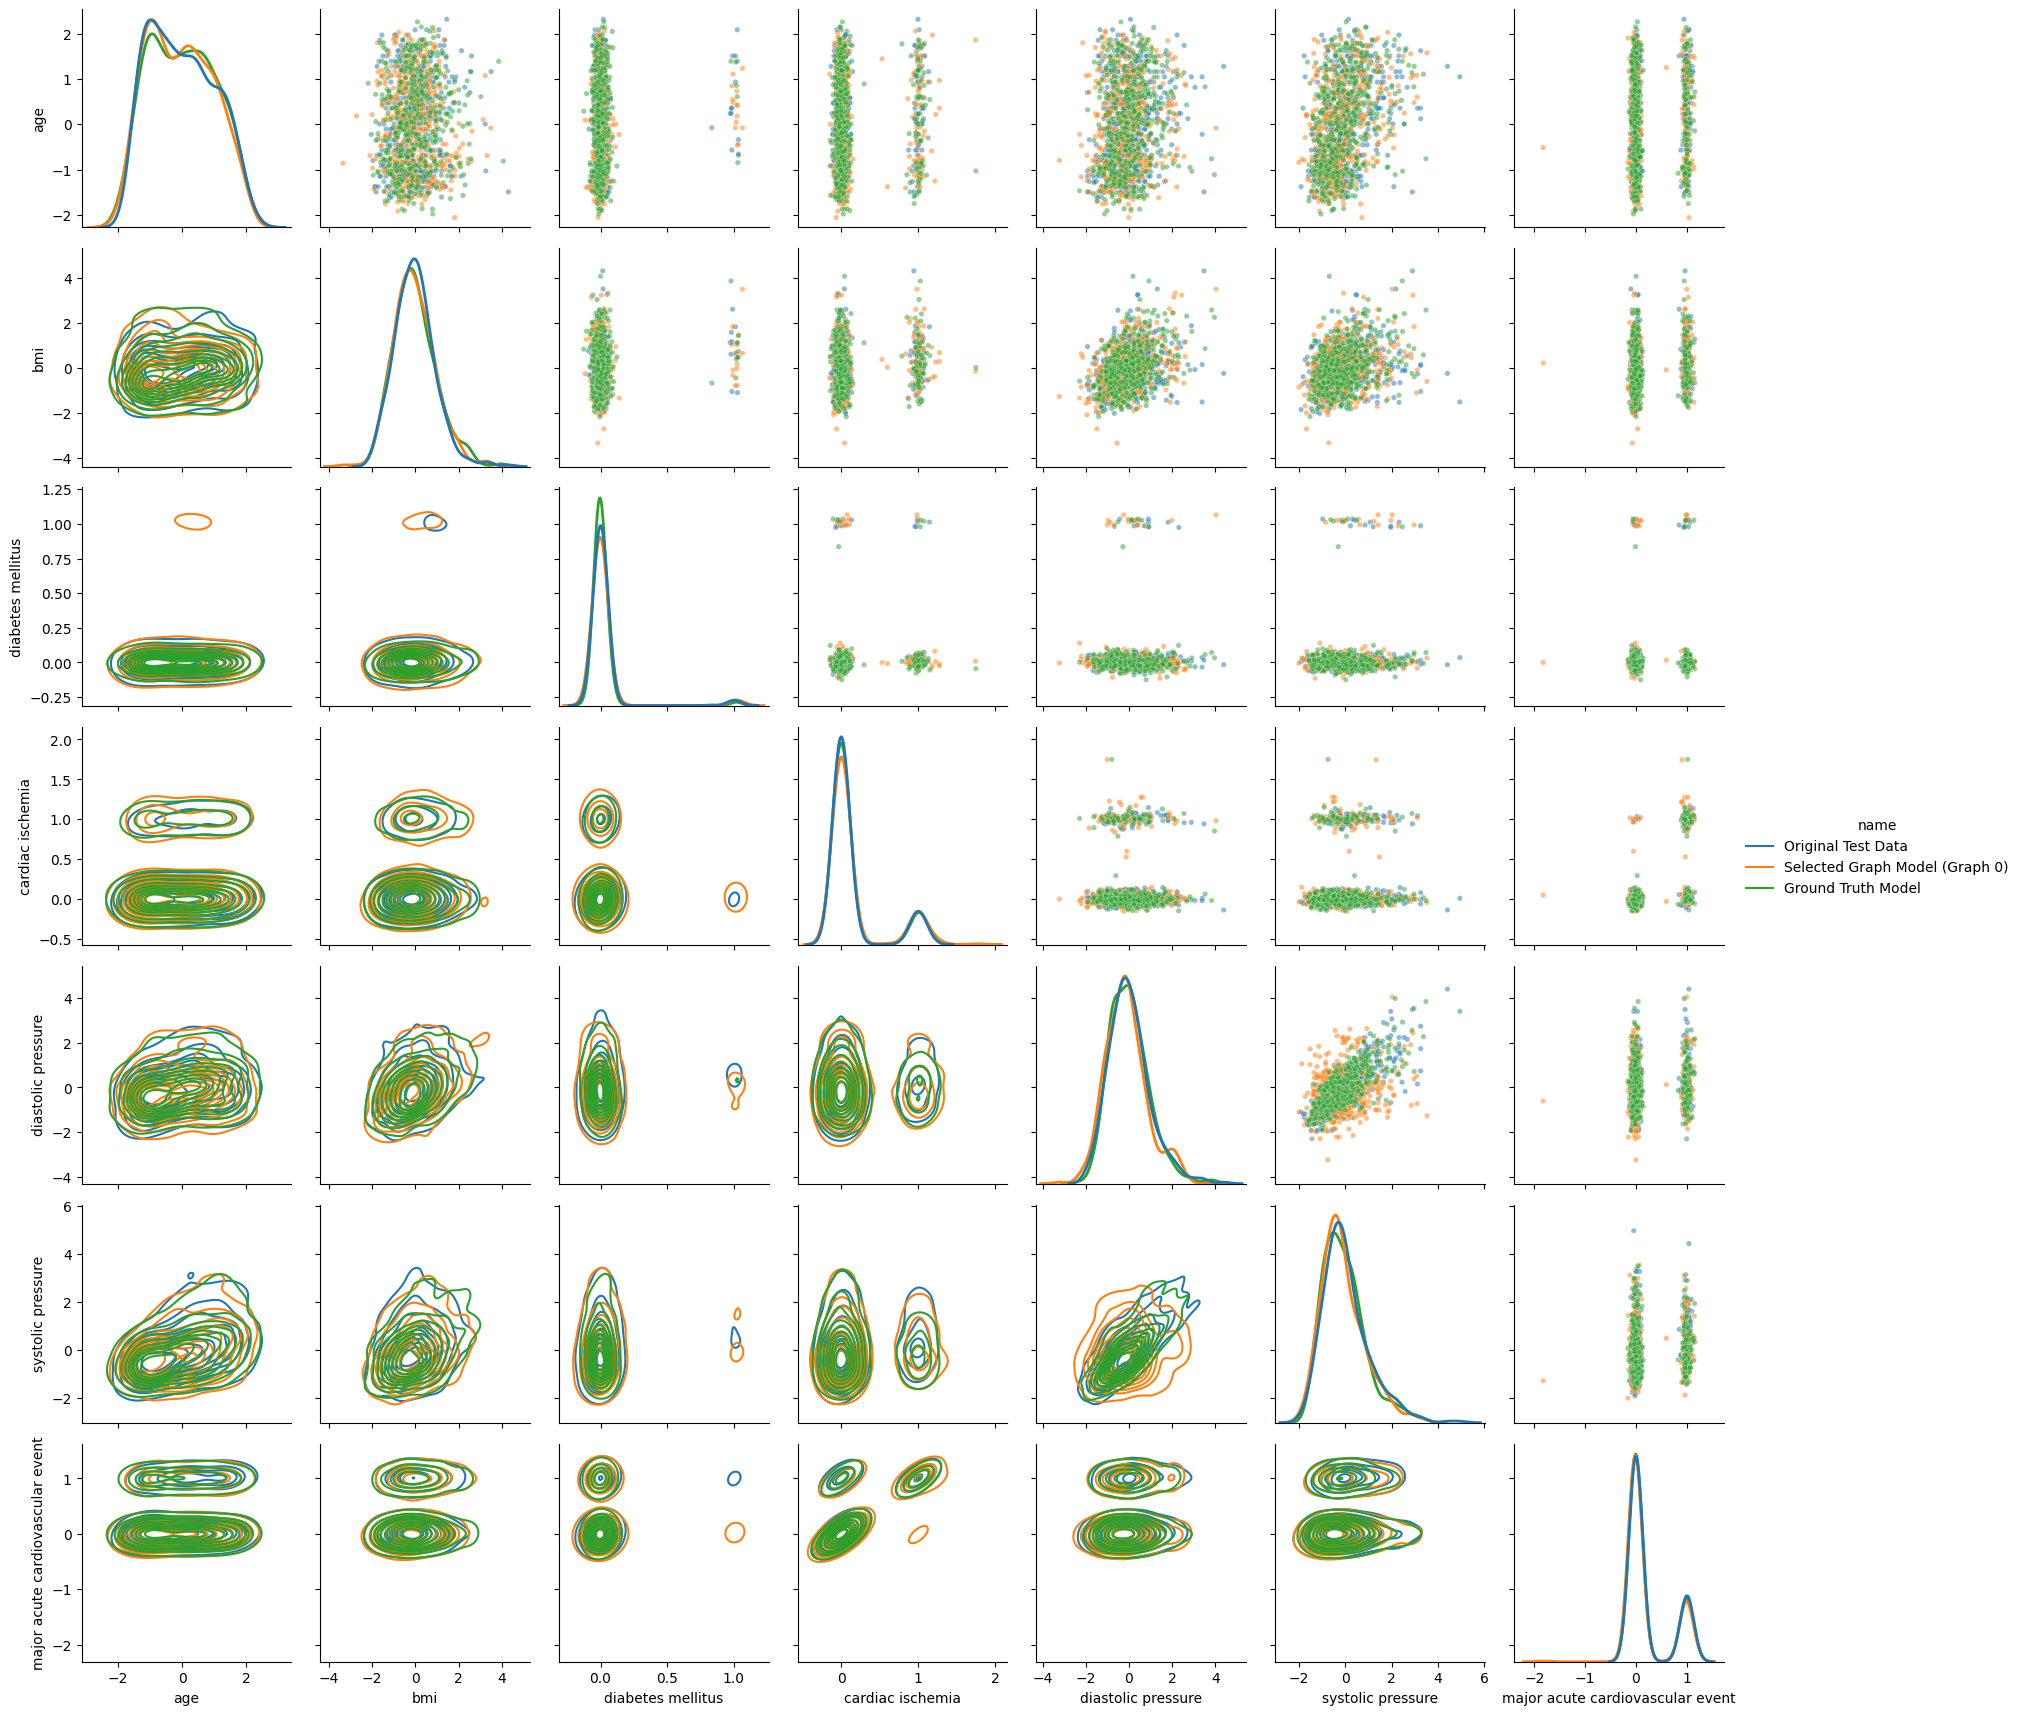

In [ ]:
test_size= len(test_data)
model_idx = 0
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

# test_data YA está en orden GT (porque data_df = data_df[gt_variables])
# Solo necesitas reordenar gen_data_selected desde Graph 0 order → GT order
reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

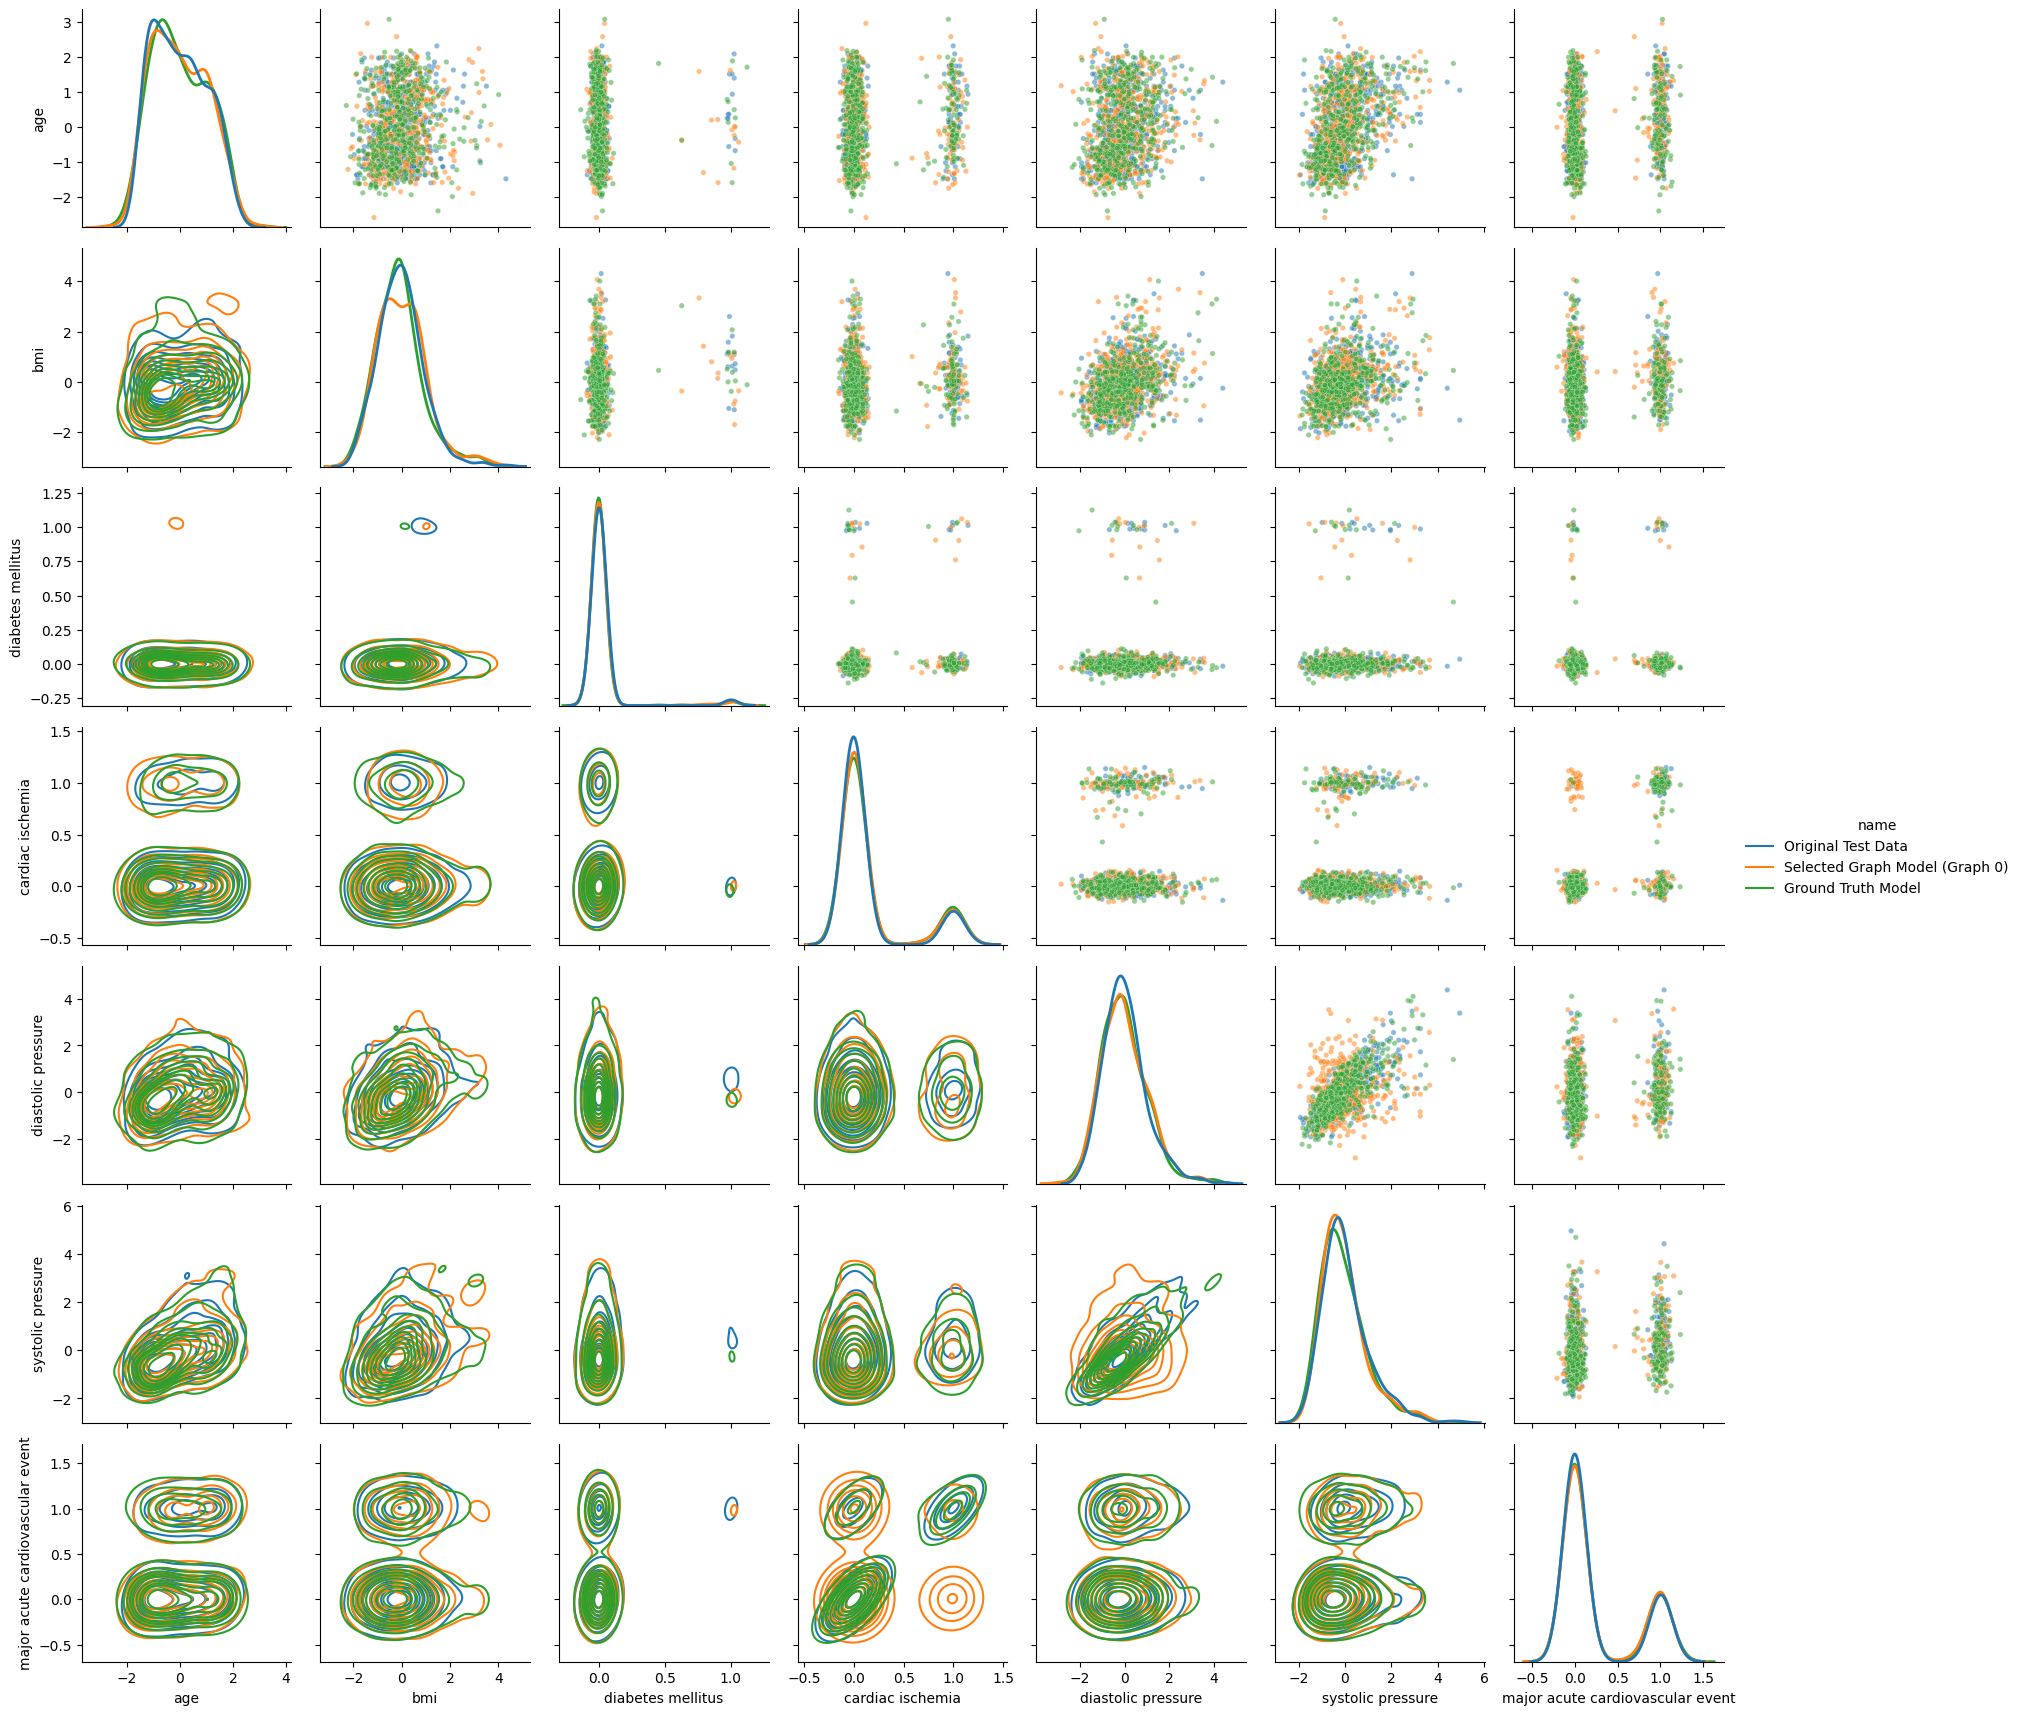

In [14]:
test_size= len(test_data)
model_idx = 1
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

# Interventions


In [14]:
def intervention_ate(
    flow_model,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    variables_selected,
    gt_variables,
    continuous_vars,
    scaler_selected,
    scaler_gt,
    test_size
):
    """
    Compute ATE for an intervention on a variable for a given model and ground truth.

    Args:
        flow_model: Trained CausalNSF model for selected graph.
        flow_gt: Trained CausalNSF model for ground truth graph.
        intervention_var: Variable name to intervene on.
        intervention_values: List of two values for intervention.
        outcome_var: Variable name for outcome.
        variables_selected: Variable order for selected graph.
        gt_variables: Variable order for ground truth.
        continuous_vars: List of continuous variable names.
        scaler_selected: Scaler for selected graph.
        scaler_gt: Scaler for ground truth graph.
        test_size: Number of samples to generate.

    Returns:
        Dictionary with means and ATEs for selected and ground truth models.
    """
    # Only use ground truth variables that are present in the selected graph
    gt_vars_in_selected = [var for var in gt_variables if var in variables_selected]
    if outcome_var not in gt_vars_in_selected:
        raise ValueError(f"Outcome variable '{outcome_var}' not in selected graph variables.")

    intervention_index_selected = variables_selected.index(intervention_var)
    continuous_indices_selected = [variables_selected.index(c) for c in continuous_vars if c in variables_selected]

    intervention_index_gt = gt_variables.index(intervention_var)
    continuous_indices_gt = [gt_variables.index(c) for c in continuous_vars if c in gt_variables]

    outcome_index_gt = gt_vars_in_selected.index(outcome_var)

    # Selected graph: generate samples in its variable order
    samples_0_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the selected model
    samples_0_selected_denorm = samples_0_selected.copy()
    samples_1_selected_denorm = samples_1_selected.copy()
    if len(continuous_indices_selected) > 0:
        samples_0_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_0_selected[:, continuous_indices_selected]
        )
        samples_1_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_1_selected[:, continuous_indices_selected]
        )

    # Reorder only the variables present in both selected and ground truth
    reorder_indices = [variables_selected.index(var) for var in gt_vars_in_selected]
    samples_0_selected_denorm_gt = samples_0_selected_denorm[:, reorder_indices]
    samples_1_selected_denorm_gt = samples_1_selected_denorm[:, reorder_indices]

    # Ground truth: generate samples in its variable order
    samples_0_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the ground truth model
    samples_0_gt_denorm = samples_0_gt.copy()
    samples_1_gt_denorm = samples_1_gt.copy()
    if len(continuous_indices_gt) > 0:
        samples_0_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_0_gt[:, continuous_indices_gt]
        )
        samples_1_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_1_gt[:, continuous_indices_gt]
        )

    # Calculate means and ATE in the ground truth order (only for present variables)
    if outcome_var in continuous_vars:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].mean()
    else:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()

    ate_selected = mean_1_selected - mean_0_selected
    ate_gt = mean_1_gt - mean_0_gt

    print(f"\nSelected Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
    print(f"   ATE = {ate_selected:+.2f}")

    print(f"\nGround Truth Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
    print(f"   ATE = {ate_gt:+.2f}")

    print(f"\nDifference ATE:")
    if outcome_var in continuous_vars:
        print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
    else:
        print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")

    return {
        "mean_0_selected": mean_0_selected,
        "mean_1_selected": mean_1_selected,
        "ate_selected": ate_selected,
        "mean_0_gt": mean_0_gt,
        "mean_1_gt": mean_1_gt,
        "ate_gt": ate_gt,
        "ate_diff": abs(ate_selected - ate_gt)
    }


## 1. Intervention on BMI and see effect in systolic pressure

In [17]:
scaler= scaler_gt
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])

intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

outcome_var='systolic pressure'

### 1.1 Mean confidence interval  

In [67]:
import scipy.stats as stats

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Calculate mean and 95% confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = stats.norm.interval(
    0.99,
    loc=mean_ate_selected,
    scale=stats.sem(ate_selected_array)
)

# Calculate mean and 95% confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = stats.norm.interval(
    0.99,
    loc=mean_ate_gt,
    scale=stats.sem(ate_gt_array)
)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"95% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"95% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")



Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.63
   E[systolic pressure | do(bmi=1.02)] = 136.01
   ATE = +7.38

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.76
   E[systolic pressure | do(bmi=1.02)] = 137.76
   ATE = +8.00

Difference ATE:
   ATE_selected - ATE_gt= 0.61

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.44
   E[systolic pressure | do(bmi=1.02)] = 139.05
   ATE = +9.61

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.49
   E[systolic pressure | do(bmi=1.02)] = 136.82
   ATE = +8.33

Difference ATE:
   ATE_selected - ATE_gt= 1.28

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 127.49
   E[systolic pressure | do(bmi=1.02)] = 136.33
   ATE = +8.85

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.65
   E[systolic pressure | do(bmi=1.02)] = 138.16
   ATE = +6.51

Difference ATE:
   ATE_selected - ATE_gt= 2.34

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.66
   E

Mean Confidence Interval Function

In [18]:
def calculate_mean_confidence_interval(
    loaded_models,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    checkpoint_gt,
    continuous_vars,
    test_size,
    confidence_level=0.95
):
    """
    Calculate mean ATE confidence intervals for selected graphs and ground truth.
    
    Args:
        loaded_models: List of loaded model dictionaries
        flow_gt: Ground truth flow model
        intervention_var: Variable to intervene on
        intervention_values: List of intervention values [low, high]
        outcome_var: Outcome variable to measure
        checkpoint_gt: Ground truth graph 
        continuous_vars: List of continuous variable names
        test_size: Number of test samples
        confidence_level: Confidence level (default 0.95)
    
    Returns:
        Dictionary with means, confidence intervals, and arrays for both selected and GT
    """
    ate_selected_list = []
    ate_gt_list = []
    
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']
    
    # Run interventions for all models
    for model_dict in loaded_models:
        flow_selected = model_dict['flow_selected']
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=test_size
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])
    
    # Calculate statistics for selected graphs
    ate_selected_array = np.array(ate_selected_list)
    mean_ate_selected = ate_selected_array.mean()
    conf_int_selected = stats.norm.interval(
        confidence_level,
        loc=mean_ate_selected,
        scale=stats.sem(ate_selected_array)
    )
    
    # Calculate statistics for ground truth
    ate_gt_array = np.array(ate_gt_list)
    mean_ate_gt = ate_gt_array.mean()
    conf_int_gt = stats.norm.interval(
        confidence_level,
        loc=mean_ate_gt,
        scale=stats.sem(ate_gt_array)
    )
    
    # Print results
    print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
    print(f"{int(confidence_level*100)}% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
    print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
    print(f"{int(confidence_level*100)}% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")
    
    return {
        'ate_selected_array': ate_selected_array,
        'mean_ate_selected': mean_ate_selected,
        'conf_int_selected': conf_int_selected,
        'ate_gt_array': ate_gt_array,
        'mean_ate_gt': mean_ate_gt,
        'conf_int_gt': conf_int_gt
    }
# Example usage

results = calculate_mean_confidence_interval(
    loaded_models=loaded_models,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    checkpoint_gt=checkpoint_gt,
    continuous_vars=continuous_vars,
    test_size=len(test_data),
    confidence_level=0.95
)


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.69
   E[systolic pressure | do(bmi=1.02)] = 136.66
   ATE = +5.97

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.79
   E[systolic pressure | do(bmi=1.02)] = 135.56
   ATE = +6.77

Difference ATE:
   ATE_selected - ATE_gt= 0.80

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.69
   E[systolic pressure | do(bmi=1.02)] = 137.52
   ATE = +6.83

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.43
   E[systolic pressure | do(bmi=1.02)] = 138.57
   ATE = +8.14

Difference ATE:
   ATE_selected - ATE_gt= 1.31

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.41
   E[systolic pressure | do(bmi=1.02)] = 136.23
   ATE = +5.81

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.27
   E[systolic pressure | do(bmi=1.02)] = 139.38
   ATE = +9.11

Difference ATE:
   ATE_selected - ATE_gt= 3.30

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.00
   E

In [78]:
gt_variables

['age',
 'bmi',
 'diabetes mellitus',
 'cardiac ischemia',
 'diastolic pressure',
 'systolic pressure',
 'major acute cardiovascular event']

### 1.2. Coverage interval Gaussian and Bootstrapping

In [25]:
# # if each individual ATE ground truth is within the prediction interval of selected graphs
def calculate_coverage_intervals(
    loaded_models,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    checkpoint_gt,
    continuous_vars,
    test_data
):
    """
    Calculate coverage intervals for ATE estimates from selected graphs.
    """

    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    for model_dict in loaded_models:
        flow_selected = model_dict['flow_selected']
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        scaler_gt = checkpoint_gt['scaler']
        gt_variables = checkpoint_gt['variables']

        # Skip if intervention variable not in this graph
        if intervention_var not in variables_selected:
            skipped_models += 1
            continue
        
        # Skip if outcome variable not in this graph
        if outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=len(test_data)
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        print(f"No models contained both '{intervention_var}' and '{outcome_var}'")
        return {
            'coverage_gaussian_95': np.nan,
            'coverage_bootstrap': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_gt_array = np.array(ate_gt_list)
    ate_selected_array = np.array(ate_selected_list)

    mean_ate_selected = ate_selected_array.mean()
    std_ate_selected = ate_selected_array.std()

    k_gaussian_95 = 1.96

    coverage_interval_gaussian_95 = (
        mean_ate_selected - k_gaussian_95 * std_ate_selected,
        mean_ate_selected + k_gaussian_95 * std_ate_selected
    )

    coverage_interval_bootstrap = (
        np.percentile(ate_selected_array, 2.5), # left bound
        np.percentile(ate_selected_array, 97.5) # right bound
    )

    # Check coverage for each individual GT ATE
    coverage_gaussian_95 = np.mean(
        (ate_gt_array >= coverage_interval_gaussian_95[0]) & 
        (ate_gt_array <= coverage_interval_gaussian_95[1])
    )

    coverage_bootstrap = np.mean(
        (ate_gt_array >= coverage_interval_bootstrap[0]) & 
        (ate_gt_array <= coverage_interval_bootstrap[1])
    )

    print("\nSelected Graphs ATE")
    print(f"Mean: {mean_ate_selected:.4f}, Std: {std_ate_selected:.4f}")
    print(f"Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    print("\nPrediction Intervals from Selected Graphs")
    print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
    print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

    print("\nCoverage Analysis Proportion of GT ATEs falling inside intervals")
    print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of GT ATEs fall inside")
    print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of GT ATEs fall inside")

    return {
        'coverage_gaussian_95': coverage_gaussian_95,
        'coverage_bootstrap': coverage_bootstrap,
        'skipped_models': skipped_models,
        'valid_models': len(ate_selected_array)
    }

## 2. Intervention on age and see effect in diabetes mellitus 

In [76]:
scaler = scaler_gt

# Encuentra el índice de 'age' en continuous_vars (orden del scaler)
age_scaler_index = continuous_vars.index('age')

# Obtén media y std del scaler
age_mean = scaler.mean_[age_scaler_index]
age_std = np.sqrt(scaler.var_[age_scaler_index])

# Define la variable de intervención
intervention_var = 'age'  
intervention_index = gt_variables.index(intervention_var)

# Normaliza los valores de intervención
intervention_values = [40.0, 70.0]  # Age young vs old
intervention_values = [float((val - age_mean) / age_std) for val in intervention_values]
intervention_values

outcome_var = 'diabetes mellitus'
outcome_index = gt_variables.index(outcome_var)


In [28]:
import scipy.stats as stats
import numpy as np

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Bootstrap confidence interval function
def bootstrap_ci(data, n_bootstrap=1000, ci=0.99):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1-ci)/2*100)
    upper = np.percentile(means, (1+ci)/2*100)
    return lower, upper

# Calculate mean and bootstrap confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = bootstrap_ci(ate_selected_array, n_bootstrap=1000, ci=0.95)

# Calculate mean and bootstrap confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = bootstrap_ci(ate_gt_array, n_bootstrap=1000, ci=0.95)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"Bootstrap 99% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"Bootstrap 99% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")


Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.04

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.04

Difference ATE:
   ATE_selected - ATE_gt = 0.5%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.00

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.04
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.03
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 2.7%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.03
   E[diabetes mellitus | do

coverage con bootstrapping

 en gaussiana media normal +- 3sigma
queremos ver donde donde caen las muestras este intervalo es distinro a la media

covergae gaussiana y coverage bootstraping las dos 
establecer una variable objetivo e ir interviniendo en todas
vector 1 o 0  si cae o no cae el valor dentro del intervalo


In [42]:
# if each individual ATE ground truth is within the prediction interval of selected graphs
ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

ate_gt_array = np.array(ate_gt_list)
ate_selected_array = np.array(ate_selected_list)

mean_ate_selected = ate_selected_array.mean()
std_ate_selected = ate_selected_array.std()

k_gaussian_95 = 1.96

coverage_interval_gaussian_95 = (
    mean_ate_selected - k_gaussian_95 * std_ate_selected,
    mean_ate_selected + k_gaussian_95 * std_ate_selected
)

coverage_interval_bootstrap = (
    np.percentile(ate_selected_array, 2.5),
    np.percentile(ate_selected_array, 97.5)
)

# Check coverage for EACH individual GT ATE
coverage_gaussian_95 = np.mean(
    (ate_gt_array >= coverage_interval_gaussian_95[0]) & 
    (ate_gt_array <= coverage_interval_gaussian_95[1])
)

coverage_gaussian_997 = np.mean(
    (ate_gt_array >= coverage_interval_gaussian_997[0]) & 
    (ate_gt_array <= coverage_interval_gaussian_997[1])
)

coverage_bootstrap = np.mean(
    (ate_gt_array >= coverage_interval_bootstrap[0]) & 
    (ate_gt_array <= coverage_interval_bootstrap[1])
)

print("\nSelected Graphs ATE")
print(f"Mean: {mean_ate_selected:.4f}, Std: {std_ate_selected:.4f}")
print(f"Number of models: {len(ate_selected_array)}")

print("\nPrediction Intervals from Selected Graphs")
print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

print("\nCoverage Analysis: Proportion of GT ATEs falling inside intervals")
print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of GT ATEs fall inside")
print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of GT ATEs fall inside")


Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.01

Difference ATE:
   ATE_selected - ATE_gt = 0.5%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.05
   ATE = +0.02

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.05
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 0.9%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.02

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 0.0%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do

In [77]:
coverage_results2 = calculate_coverage_intervals(
    loaded_models=loaded_models,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    checkpoint_gt=checkpoint_gt,
    continuous_vars=continuous_vars,
    test_data=test_data
)


Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.00
   E[diabetes mellitus | do(age=2.31)] = 0.07
   ATE = +0.07

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.06
   ATE = +0.05

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.03
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.00

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.00
   E[diabetes mellitus | do(age=2.31)] = 0.04
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 3.2%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do

In [79]:
gt_variables

['age',
 'bmi',
 'diabetes mellitus',
 'cardiac ischemia',
 'diastolic pressure',
 'systolic pressure',
 'major acute cardiovascular event']

## 3. Intervention: Establish one target variable and intervene on all other variables

In [ ]:
# Define target variable
target_var = 'major acute cardiovascular event'

# Get all variables except the target
intervention_vars = [var for var in gt_variables if var != target_var]

# Storage for results
all_coverage_results = {}

# Define intervention values for each variable
def get_intervention_values(var_name, scaler_gt, continuous_vars, gt_variables):
    """
    Get appropriate intervention values for a variable.
    
    Args:
        var_name: Name of the variable
        scaler_gt: Ground truth scaler
        continuous_vars: List of continuous variable names
        gt_variables: List of all ground truth variables
    
    Returns:
        List of two intervention values [low, high]
    """
    if var_name in continuous_vars:
        # For continuous variables, use scaler statistics
        scaler_index = continuous_vars.index(var_name)
        var_mean = scaler_gt.mean_[scaler_index]
        var_std = np.sqrt(scaler_gt.var_[scaler_index])
        
        # Define intervention ranges based on variable type
        if var_name == 'age':
            raw_values = [40.0, 70.0]  # Young vs old
        elif var_name == 'bmi':
            raw_values = [24.0, 30.0]  # Normal vs obese
        elif var_name == 'systolic pressure':
            raw_values = [110.0, 140.0]  # Normal vs high
        elif var_name == 'diastolic pressure':
            raw_values = [70.0, 90.0]  # Normal vs high
        else:
            # Generic: mean ± 1.5 std
            raw_values = [var_mean - 1.5 * var_std, var_mean + 1.5 * var_std]
        
        # Normalize values
        normalized_values = [float((val - var_mean) / var_std) for val in raw_values]
        return normalized_values
    else:
        # For binary variables (cardiac ischemia, diabetes mellitus)
        return [0.0, 1.0]

# Loop through all intervention variables
print(f"TARGET OUTCOME: {target_var}")
print(f"Running interventions on {len(intervention_vars)} variables")

for intervention_var in tqdm(intervention_vars, desc="Processing interventions"):
    print(f"Intervention: {intervention_var} → Outcome: {target_var}")
    
    # Get intervention values
    intervention_values = get_intervention_values(
        intervention_var, 
        scaler_gt, 
        continuous_vars, 
        gt_variables
    )
    
    var_type = "continuous" if intervention_var in continuous_vars else "binary"
    print(f"Variable type: {var_type}")
    print(f"Intervention values: {intervention_values}")
    
    # Calculate coverage intervals
    coverage_results = calculate_coverage_intervals(
        loaded_models=loaded_models,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=target_var,
        checkpoint_gt=checkpoint_gt,
        continuous_vars=continuous_vars,
        test_data=test_data
    )
    
    # Store results with all fields from coverage_results
    all_coverage_results[intervention_var] = {
        'variable_type': var_type,
        'intervention_values': intervention_values,
        'coverage_gaussian_95': coverage_results['coverage_gaussian_95'],
        'coverage_bootstrap': coverage_results['coverage_bootstrap'],
        'valid_models': coverage_results['valid_models'],
        'skipped_models': coverage_results['skipped_models']
    }

# Create summary DataFrame
summary_data = []
for var, results in all_coverage_results.items():
    if results['variable_type'] == 'continuous':
        interv_str = f"{results['intervention_values'][0]:.2f} → {results['intervention_values'][1]:.2f}"
    else:
        interv_str = "0 → 1"
    
    # Handle NaN values
    cov_gauss = results['coverage_gaussian_95']
    cov_boot = results['coverage_bootstrap']
    
    summary_data.append({
        'Intervention Variable': var,
        'Type': results['variable_type'],
        'Intervention Values': interv_str,
        'Coverage Gaussian 95%': f"{cov_gauss:.1%}" if not np.isnan(cov_gauss) else "N/A",
        'Coverage Bootstrap 95%': f"{cov_boot:.1%}" if not np.isnan(cov_boot) else "N/A",
        'Valid Models': results.get('valid_models', 'N/A'),
        'Skipped Models': results.get('skipped_models', 'N/A')
    })

summary_df = pd.DataFrame(summary_data)

In [ ]:
print(f"SUMMARY: All interventions → '{target_var}'")
print(summary_df.to_string(index=False))

# Calculate average coverage (excluding NaN values)
valid_results = [r for r in all_coverage_results.values() 
                if not np.isnan(r['coverage_gaussian_95'])]

avg_coverage_gaussian = np.mean([r['coverage_gaussian_95'] for r in valid_results])
avg_coverage_bootstrap = np.mean([r['coverage_bootstrap'] for r in valid_results])

print(f"AVERAGE COVERAGE ACROSS ALL INTERVENTIONS")
print(f"Gaussian 95%:   {avg_coverage_gaussian:.1%}")
print(f"Bootstrap 95%:  {avg_coverage_bootstrap:.1%}")
print(f"Valid interventions: {len(valid_results)}/{len(all_coverage_results)}")

SUMMARY: All interventions → 'major acute cardiovascular event'
Intervention Variable       Type Intervention Values Coverage Gaussian 95% Coverage Bootstrap 95%  Valid Models  Skipped Models
                  age continuous        -1.14 → 2.31                100.0%                 100.0%           100               0
                  bmi continuous        -0.45 → 1.02                 95.0%                  95.0%           100               0
    diabetes mellitus     binary               0 → 1                100.0%                 100.0%           100               0
     cardiac ischemia     binary               0 → 1                100.0%                  73.7%            99               1
   diastolic pressure continuous        -1.09 → 0.57                100.0%                 100.0%           100               0
    systolic pressure continuous        -1.03 → 0.31                100.0%                  99.0%           100               0
AVERAGE COVERAGE ACROSS ALL INTERVENTION

In [ ]:
# # Save summary table to CSV
# summary_df.to_csv('coverage_summary.csv', index=False)


### 4. Interventions all

In [ ]:

def get_intervention_values(var_name, scaler_gt, continuous_vars, gt_variables):
    """Get intervention values for a variable."""
    if var_name in continuous_vars:
        scaler_index = continuous_vars.index(var_name)
        var_mean = scaler_gt.mean_[scaler_index]
        var_std = np.sqrt(scaler_gt.var_[scaler_index])
        
        # Define intervention ranges
        interventions = {
            'age': [40.0, 70.0],
            'bmi': [24.0, 30.0],
            'systolic pressure': [110.0, 140.0],
            'diastolic pressure': [70.0, 90.0]
        }
        raw_values = interventions.get(var_name, [var_mean - 1.5 * var_std, var_mean + 1.5 * var_std])
        return [float((val - var_mean) / var_std) for val in raw_values]
    else:
        return [0.0, 1.0]

# Main loop
all_targets_results = {}


for target_var in tqdm(gt_variables, desc="Processing targets"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(intervention_var, scaler_gt, continuous_vars, gt_variables)
        
        coverage_results = calculate_coverage_intervals(
            loaded_models=loaded_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=test_data
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results[target_var] = target_coverage_results

nota: skip models that do not contain the intervention variable or the outcome variable

In [100]:
rows = []
for target_var, interventions in all_targets_results.items():
    for intervention_var, results in interventions.items():
        rows.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

# Create comprehensive DataFrame
df_all_interventions = pd.DataFrame(rows)
df_all_interventions

,Target Variable,Target Type,Intervention Variable,Intervention Type,Intervention Low,Intervention High,Coverage Gaussian 95%,Coverage Bootstrap 95%,Valid Models,Skipped Models
0,age,continuous,bmi,continuous,-0.449020,1.015528,0.950000,0.950000,100,0
1,age,continuous,diabetes mellitus,binary,0.000000,1.000000,0.970000,0.970000,100,0
2,age,continuous,cardiac ischemia,binary,0.000000,1.000000,0.939394,0.919192,99,1
3,age,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.990000,0.990000,100,0
4,age,continuous,systolic pressure,continuous,-1.026206,0.312048,0.940000,0.940000,100,0
5,age,continuous,major acute cardiovascular event,binary,0.000000,1.000000,0.970000,0.960000,100,0
6,bmi,continuous,age,continuous,-1.144059,2.313775,1.000000,0.760000,100,0
7,bmi,continuous,diabetes mellitus,binary,0.000000,1.000000,0.970000,0.970000,100,0
8,bmi,continuous,cardiac ischemia,binary,0.000000,1.000000,0.949495,0.919192,99,1
9,bmi,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.940000,0.940000,100,0


especificar que estos resultados son buenos en este dataset, pero se podria probar en otro context
linea futura, limitaciones : comparar con otros datasets

promedio coverage por variable de output 
promedio 
skipped models en la memoria 1 

Notes

we could also do if the mean ATE ground truth is within the prediction interval of selected graphs

Comparing Means vs. Distributions
we are checking if one mean (GT) falls within the prediction interval of another distribution (selected graphs). Can we do this?

 Does mean(GT) fall within prediction_interval(selected)? ->  Gaussian prediction interval assumes normality of individual ATEs. But we have:100 models with different graph structures Each produces one ATE estimate
This is not the same as sampling from a single distribution

bootstraping percentiles intervals make more sense
What makes more sense: Does the GT distribution overlap with the selected distribution?

In [38]:
# Build GT prediction interval 
gt_interval_bootstrap = (
    np.percentile(ate_gt_array, 2.5),
    np.percentile(ate_gt_array, 97.5)
)

# Check overlap
intervals_overlap = not (
    coverage_interval_bootstrap[1] < gt_interval_bootstrap[0] or
    coverage_interval_bootstrap[0] > gt_interval_bootstrap[1]
)

print(f"Intervals overlap: {'YES' if intervals_overlap else 'NO'}")

Intervals overlap: YES


### Compare with no graph model

In [ ]:
# Load the model without graph structure
checkpoint_no_graph = torch.load(
    'saved_models_validation/flow_no_graph.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)

flow_no_graph = CausalNSF(
    checkpoint_no_graph['features'],
    0,
    order=checkpoint_no_graph['order'],
    hidden_features=checkpoint_no_graph['config']['hidden_dims']
)
flow_no_graph.load_state_dict(checkpoint_no_graph['model_state_dict'])
flow_no_graph.eval()

scaler_no_graph = checkpoint_no_graph['scaler']
variables_no_graph = checkpoint_no_graph['variables']

print(f"Loaded no-graph model")

Loaded no-graph model


In [16]:
scaler= scaler_gt
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])

intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

outcome_var='systolic pressure'

In [22]:
ate_selected_list = []
ate_gt_list = []

result = intervention_ate(
    flow_model=flow_no_graph,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    variables_selected=variables_no_graph,
    gt_variables=gt_variables,
    continuous_vars=continuous_vars,
    scaler_selected=scaler_no_graph,
    scaler_gt=scaler_gt,
    test_size=len(test_data)
)
ate_selected_list.append(result['ate_selected'])
ate_gt_list.append(result['ate_gt'])


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.42
   E[systolic pressure | do(bmi=1.02)] = 140.89
   ATE = +9.47

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.85
   E[systolic pressure | do(bmi=1.02)] = 137.55
   ATE = +7.70

Difference ATE:
   ATE_selected - ATE_gt= 1.77


## Interventions all with no graph

In [41]:
# Create 100 references to the same no-graph model
no_graph_models = []
for i in range(100):
    no_graph_models.append({
        'flow_selected': flow_no_graph,
        'variables': variables_no_graph,
        'scaler': scaler_no_graph
    })

print(f"Created {len(no_graph_models)} no-graph model instances for sampling")

Created 100 no-graph model instances for sampling


In [ ]:
# Run the same intervention analysis with no-graph model (100 samples)
all_targets_results_no_graph = {}

for target_var in tqdm(gt_variables, desc="Processing targets (no-graph)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals(
            loaded_models=no_graph_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=test_data
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_no_graph[target_var] = target_coverage_results

# Create DataFrame for no-graph results
rows_no_graph = []
for target_var, interventions in all_targets_results_no_graph.items():
    for intervention_var, results in interventions.items():
        rows_no_graph.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_no_graph_interventions = pd.DataFrame(rows_no_graph)
df_no_graph_interventions

In [46]:
# Calculate average coverage for knowledge graph models
valid_kg = [r for target in all_targets_results.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_kg_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_kg])
avg_cov_kg_boot = np.mean([r['coverage_bootstrap'] for r in valid_kg])

# Calculate average coverage for no-graph model
valid_ng = [r for target in all_targets_results_no_graph.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_ng_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_ng])
avg_cov_ng_boot = np.mean([r['coverage_bootstrap'] for r in valid_ng])

print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS")
print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")

print(f"\nNO-GRAPH MODEL")
print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")




KNOWLEDGE GRAPH ESTIMATED MODELS
  Average Gaussian Coverage:   92.2%
  Average Bootstrap Coverage:  90.2%

NO-GRAPH MODEL
  Average Gaussian Coverage:   79.7%
  Average Bootstrap Coverage:  78.8%


### Ground truth intervals for all variables

Modified the function to calculate the confidence intervals for the ground truth and calculate the coverage for the estimated graph samples

In [28]:
def calculate_coverage_intervals_inverse(
    loaded_models,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    checkpoint_gt,
    continuous_vars,
    test_data
):
    """
    Calculate coverage intervals with GT as reference and estimated models as samples.
    """
    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    for model_dict in loaded_models:
        flow_selected = model_dict['flow_selected']
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        scaler_gt = checkpoint_gt['scaler']
        gt_variables = checkpoint_gt['variables']

        if intervention_var not in variables_selected or outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=len(test_data)
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        return {
            'coverage_gaussian_95': np.nan,
            'coverage_bootstrap': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_gt_array = np.array(ate_gt_list)
    ate_selected_array = np.array(ate_selected_list)

    mean_ate_gt = ate_gt_array.mean()
    std_ate_gt = ate_gt_array.std()

    k_gaussian_95 = 1.96

    coverage_interval_gaussian_95 = (
        mean_ate_gt - k_gaussian_95 * std_ate_gt,
        mean_ate_gt + k_gaussian_95 * std_ate_gt
    )

    coverage_interval_bootstrap = (
        np.percentile(ate_gt_array, 2.5),
        np.percentile(ate_gt_array, 97.5)
    )

    coverage_gaussian_95 = np.mean(
        (ate_selected_array >= coverage_interval_gaussian_95[0]) & 
        (ate_selected_array <= coverage_interval_gaussian_95[1])
    )

    coverage_bootstrap = np.mean(
        (ate_selected_array >= coverage_interval_bootstrap[0]) & 
        (ate_selected_array <= coverage_interval_bootstrap[1])
    )

    print("\nGround Truth ATE")
    print(f"Mean: {mean_ate_gt:.4f}, Std: {std_ate_gt:.4f}")
    print(f"Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    print("\nPrediction Intervals from Ground Truth")
    print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
    print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

    print("\nCoverage Analysis: Proportion of Estimated ATEs falling inside GT intervals")
    print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of estimated ATEs fall inside")
    print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of estimated ATEs fall inside")

    return {
        'coverage_gaussian_95': coverage_gaussian_95,
        'coverage_bootstrap': coverage_bootstrap,
        'skipped_models': skipped_models,
        'valid_models': len(ate_selected_array)
    }


This is the same as before no modification needed

functions defined: 

intervention_ate
get_intervention_values

In [ ]:
all_targets_results_inverse = {}

for target_var in tqdm(gt_variables, desc="Processing targets"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(intervention_var, scaler_gt, continuous_vars, gt_variables)
        
        coverage_results = calculate_coverage_intervals_inverse(
            loaded_models=loaded_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=test_data
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_inverse[target_var] = target_coverage_results

In [20]:
rows = []
for target_var, interventions in all_targets_results_inverse.items():
    for intervention_var, results in interventions.items():
        rows.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

# Create comprehensive DataFrame
df_all_interventions = pd.DataFrame(rows)
df_all_interventions

,Target Variable,Target Type,Intervention Variable,Intervention Type,Intervention Low,Intervention High,Coverage Gaussian 95%,Coverage Bootstrap 95%,Valid Models,Skipped Models
0,age,continuous,bmi,continuous,-0.449020,1.015528,0.870000,0.860000,100,0
1,age,continuous,diabetes mellitus,binary,0.000000,1.000000,0.910000,0.900000,100,0
2,age,continuous,cardiac ischemia,binary,0.000000,1.000000,0.979798,0.949495,99,1
3,age,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.930000,0.900000,100,0
4,age,continuous,systolic pressure,continuous,-1.026206,0.312048,0.940000,0.910000,100,0
5,age,continuous,major acute cardiovascular event,binary,0.000000,1.000000,0.930000,0.920000,100,0
6,bmi,continuous,age,continuous,-1.144059,2.313775,0.340000,0.300000,100,0
7,bmi,continuous,diabetes mellitus,binary,0.000000,1.000000,0.970000,0.930000,100,0
8,bmi,continuous,cardiac ischemia,binary,0.000000,1.000000,0.949495,0.919192,99,1
9,bmi,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.870000,0.890000,100,0


NO graph GROUND TRUTH intervals

In [18]:
# Load the model without graph structure
checkpoint_no_graph = torch.load(
    'saved_models_validation/flow_no_graph.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)

flow_no_graph = CausalNSF(
    checkpoint_no_graph['features'],
    0,
    order=checkpoint_no_graph['order'],
    hidden_features=checkpoint_no_graph['config']['hidden_dims']
)
flow_no_graph.load_state_dict(checkpoint_no_graph['model_state_dict'])
flow_no_graph.eval()

scaler_no_graph = checkpoint_no_graph['scaler']
variables_no_graph = checkpoint_no_graph['variables']

print(f"Loaded no-graph model")

Loaded no-graph model


In [ ]:
# Create 100 references to the same no-graph model

no_graph_models = []
for i in range(100):
    no_graph_models.append({
        'flow_selected': flow_no_graph,
        'variables': variables_no_graph,
        'scaler': scaler_no_graph
    })

print(f"Created {len(no_graph_models)} no-graph model instances for sampling")

# Run intervention analysis with no-graph model using GT intervals
all_targets_results_no_graph_inverse = {}

for target_var in tqdm(gt_variables, desc="Processing targets (no-graph inverse)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals_inverse(
            loaded_models=no_graph_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=test_data
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_no_graph_inverse[target_var] = target_coverage_results


In [21]:
# Create DataFrame for no-graph inverse results
rows_no_graph_inverse = []
for target_var, interventions in all_targets_results_no_graph_inverse.items():
    for intervention_var, results in interventions.items():
        rows_no_graph_inverse.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_no_graph_interventions_inverse = pd.DataFrame(rows_no_graph_inverse)
df_no_graph_interventions_inverse

,Target Variable,Target Type,Intervention Variable,Intervention Type,Intervention Low,Intervention High,Coverage Gaussian 95%,Coverage Bootstrap 95%,Valid Models,Skipped Models
0,age,continuous,bmi,continuous,-0.449020,1.015528,0.96,0.94,100,0
1,age,continuous,diabetes mellitus,binary,0.000000,1.000000,0.97,0.97,100,0
2,age,continuous,cardiac ischemia,binary,0.000000,1.000000,0.91,0.88,100,0
3,age,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.96,0.96,100,0
4,age,continuous,systolic pressure,continuous,-1.026206,0.312048,0.97,0.97,100,0
5,age,continuous,major acute cardiovascular event,binary,0.000000,1.000000,0.89,0.91,100,0
6,bmi,continuous,age,continuous,-1.144059,2.313775,0.94,0.90,100,0
7,bmi,continuous,diabetes mellitus,binary,0.000000,1.000000,0.96,0.91,100,0
8,bmi,continuous,cardiac ischemia,binary,0.000000,1.000000,0.95,0.93,100,0
9,bmi,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.92,0.92,100,0


comparison

In [31]:
# Calculate average coverage for knowledge graph models
valid_kg = [r for target in all_targets_results_inverse.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_kg_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_kg])
avg_cov_kg_boot = np.mean([r['coverage_bootstrap'] for r in valid_kg])

# Calculate average coverage for no-graph model
valid_ng = [r for target in all_targets_results_no_graph_inverse.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_ng_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_ng])
avg_cov_ng_boot = np.mean([r['coverage_bootstrap'] for r in valid_ng])

print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS")
print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")

print(f"\nNO-GRAPH MODEL")
print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")




KNOWLEDGE GRAPH ESTIMATED MODELS
  Average Gaussian Coverage:   76.4%
  Average Bootstrap Coverage:  75.0%

NO-GRAPH MODEL
  Average Gaussian Coverage:   80.9%
  Average Bootstrap Coverage:  79.5%
